# Day 8 자율 프로젝트 제출: 한국어 뉴스 요약 서비스

---

| 항목 | 내용 |
|------|------|
| 날짜 | 2026-04-07 |
| 모델 | gogamza/kobart-summarization |
| 태스크 | summarization - 한국어 뉴스 기사 핵심 요약 |
| 디바이스 | MPS (Apple Silicon GPU) |
| FastAPI 포트 | 8000 |
| Streamlit 포트 | 8501 |

## 프로젝트 소개

---

### 1. 서비스 개요

한국어 뉴스 요약 서비스는 KoBART 모델을 이용하여 긴 뉴스 기사를 핵심 내용으로 압축합니다.
사용자는 Streamlit UI에서 기사 원문을 입력하고, FastAPI 백엔드가 KoBART 모델로 추론한 요약문을 반환합니다.

### 2. 기술 스택

| 레이어 | 기술 |
|--------|------|
| 모델 | gogamza/kobart-summarization (SKT KoBART 기반) |
| 백엔드 | FastAPI + Pydantic + Uvicorn |
| 인증 | API Key (X-API-Key 헤더) |
| 비동기 | asyncio.run_in_executor + ThreadPoolExecutor |
| 프론트엔드 | Streamlit |
| 디바이스 | MPS (Apple Silicon) |

### 3. KoBART 모델 선택 이유

BART(Bidirectional and Auto-Regressive Transformers)는 Facebook이 개발한 seq2seq 모델로,
인코더가 문서 전체를 양방향으로 이해하고, 디코더가 요약문을 순차적으로 생성합니다.
gogamza/kobart-summarization은 SKT의 KoBART를 다음 뉴스 데이터로 파인튜닝한 모델로,
한국어 뉴스 요약 태스크에 최적화되어 있습니다.

```
입력 (뉴스 기사)
      ↓
  [KoBART 인코더]  - 양방향 Attention, 문서 전체 이해
      ↓
  [KoBART 디코더]  - 단방향 Auto-Regressive, 요약문 생성
      ↓
출력 (핵심 요약문)
```

### 4. 구현 과정

1. 모델 동작 확인: 노트북에서 AutoTokenizer + AutoModelForSeq2SeqLM으로 직접 로드 후 테스트
2. schemas.py: 텍스트 길이 제한(50~5000자)과 요약 파라미터를 Pydantic으로 명세
3. model_service.py: MPS 자동 감지, load_model() / predict() 분리, SentencePiece 기호 제거
4. main.py: startup 이벤트, Depends 인증, run_in_executor 비동기 추론 조립
5. frontend/app.py: 2컬럼 레이아웃, 압축률 통계, 에러 유형별 메시지 처리

## Step 1 - 모델 동작 확인

In [1]:
# Cell 1 - KoBART 모델 동작 확인
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("MPS(Apple Silicon GPU) 사용")
else:
    device = torch.device("cpu")
    print("CPU 사용")

MODEL_NAME = "gogamza/kobart-summarization"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)
model = model.to(device)
model.eval()
print("모델 로드 완료")

test_text = (
    "서울시는 오늘 새로운 대중교통 정책을 발표했다. "
    "이번 정책은 버스와 지하철 요금 체계를 통합하고 환승 할인 혜택을 확대하는 내용을 담고 있다. "
    "시 관계자는 이번 정책으로 시민들의 교통비 부담이 연간 약 15% 감소할 것으로 예상한다고 밝혔다. "
    "특히 대중교통을 자주 이용하는 직장인과 학생들이 큰 혜택을 받을 것으로 전망된다. "
    "이번 정책은 다음 달부터 단계적으로 시행될 예정이다."
)

inputs = tokenizer(test_text, return_tensors="pt", max_length=1024, truncation=True).to(device)

with torch.no_grad():
    output_ids = model.generate(
        inputs["input_ids"],
        max_length=128,
        min_length=30,
        num_beams=4,
        length_penalty=2.0,
        early_stopping=True,
    )

summary = tokenizer.decode(output_ids[0], skip_special_tokens=True)
summary = summary.replace("▁", " ").strip()

print("[원문]")
print(test_text)
print("[요약]")
print(summary)
print(f"원문: {len(test_text)}자 → 요약: {len(summary)}자")

/Users/macminim4/Aiffel02/MLOps02/MLOps2venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MPS(Apple Silicon GPU) 사용


Loading weights: 100%|██████████| 260/260 [00:00<00:00, 24335.42it/s]


모델 로드 완료
[원문]
서울시는 오늘 새로운 대중교통 정책을 발표했다. 이번 정책은 버스와 지하철 요금 체계를 통합하고 환승 할인 혜택을 확대하는 내용을 담고 있다. 시 관계자는 이번 정책으로 시민들의 교통비 부담이 연간 약 15% 감소할 것으로 예상한다고 밝혔다. 특히 대중교통을 자주 이용하는 직장인과 학생들이 큰 혜택을 받을 것으로 전망된다. 이번 정책은 다음 달부터 단계적으로 시행될 예정이다.
[요약]
읍면동주민자치위원회는 읍면동주민자치위원회를 통해 읍면동주민자치위원회를 통해 읍면동주민자치위원회로 주민등록을 이전하고 주민등록을 이전할 예정이다.
원문: 211자 → 요약: 80자


## Step 2 - 프로젝트 구조 생성

In [2]:
# Cell 2 - 작업 디렉토리 고정 및 폴더 생성
import os
import sys

NOTEBOOK_DIR = "/Users/macminim4/Aiffel02/MLOps02/lecture08"
os.chdir(NOTEBOOK_DIR)
if NOTEBOOK_DIR not in sys.path:
    sys.path.insert(0, NOTEBOOK_DIR)

for d in ["app", "frontend"]:
    os.makedirs(d, exist_ok=True)

print(f"작업 디렉토리: {os.getcwd()}")
print("""
lecture08/
├── submitday08.ipynb
├── app/
│   ├── __init__.py
│   ├── auth.py
│   ├── schemas.py
│   ├── model_service.py
│   └── main.py
└── frontend/
    └── app.py
""")

작업 디렉토리: /Users/macminim4/Aiffel02/MLOps02/lecture08

lecture08/
├── submitday08.ipynb
├── app/
│   ├── __init__.py
│   ├── auth.py
│   ├── schemas.py
│   ├── model_service.py
│   └── main.py
└── frontend/
    └── app.py



## Step 3 - auth.py: API Key 인증 (Day 6 재사용)

In [3]:
%%writefile app/__init__.py
# app 패키지 초기화

Overwriting app/__init__.py


In [4]:
%%writefile app/auth.py
# auth.py: API Key 인증 모듈 (Day 6 재사용)
from fastapi import Header, HTTPException

VALID_API_KEYS = {
    "test-key-001": "사용자A",
    "test-key-002": "사용자B",
}


async def verify_api_key(x_api_key: str = Header(None)) -> str:
    """
    X-API-Key 헤더를 검증하는 FastAPI 의존성 함수.
    유효한 키이면 사용자 이름을 반환하고, 그렇지 않으면 401을 발생시킵니다.
    """
    if x_api_key is None:
        raise HTTPException(
            status_code=401,
            detail="API Key가 필요합니다. X-API-Key 헤더를 포함해 주세요.",
        )
    if x_api_key not in VALID_API_KEYS:
        raise HTTPException(
            status_code=401,
            detail="유효하지 않은 API Key입니다.",
        )
    return VALID_API_KEYS[x_api_key]

Overwriting app/auth.py


## Step 4 - schemas.py: 입출력 스키마 정의

In [5]:
%%writefile app/schemas.py
# schemas.py: 요청/응답 스키마
from pydantic import BaseModel, Field
from typing import Optional


class PredictRequest(BaseModel):
    """요약 요청 스키마."""
    text: str = Field(
        ...,
        min_length=50,
        max_length=5000,
        description="요약할 한국어 텍스트 (최소 50자)",
    )
    max_length: int = Field(default=128, ge=30, le=512, description="요약문 최대 토큰 수")
    min_length: int = Field(default=30, ge=10, le=200, description="요약문 최소 토큰 수")

    model_config = {
        "json_schema_extra": {
            "examples": [
                {
                    "text": (
                        "서울시는 오늘 새로운 대중교통 정책을 발표했다. "
                        "이번 정책은 버스와 지하철 요금 체계를 통합하고 환승 할인 혜택을 확대하는 내용을 담고 있다. "
                        "시 관계자는 이번 정책으로 시민들의 교통비 부담이 연간 약 15% 감소할 것으로 예상한다고 밝혔다."
                    ),
                    "max_length": 128,
                    "min_length": 30,
                }
            ]
        }
    }


class PredictResponse(BaseModel):
    """요약 응답 스키마."""
    success: bool            = Field(description="요청 처리 성공 여부")
    summary: str             = Field(description="생성된 요약문")
    original_length: int     = Field(description="원문 글자 수")
    summary_length: int      = Field(description="요약문 글자 수")
    compression_ratio: float = Field(description="압축률 (요약 / 원문)")
    model_name: str          = Field(description="사용된 모델 이름")
    user: Optional[str]      = Field(default=None, description="인증된 사용자")

Overwriting app/schemas.py


## Step 5 - model_service.py: 모델 캡슐화

In [6]:
%%writefile app/model_service.py
# model_service.py: KoBART 모델 로드 + 추론
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

MODEL_NAME = "gogamza/kobart-summarization"


def load_model() -> dict:
    """
    KoBART 토크나이저와 모델을 로드합니다.
    서버 startup 이벤트에서 1회만 호출됩니다.
    load_model()과 predict()를 분리한 이유:
      - load_model()은 서버 시작 시 1회 실행 (수십 초 소요)
      - predict()는 요청마다 실행 (수백 ms 소요)
      - 분리하지 않으면 매 요청마다 모델을 새로 로드해야 합니다.
    """
    if torch.backends.mps.is_available():
        device = torch.device("mps")
    else:
        device = torch.device("cpu")

    print(f"[model_service] 디바이스: {device}")
    print(f"[model_service] 모델 로드 중: {MODEL_NAME}")

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)
    model = model.to(device)
    model.eval()

    print("[model_service] 로드 완료")
    return {"tokenizer": tokenizer, "model": model, "device": device}


def predict(model_dict: dict, text: str, max_length: int = 128, min_length: int = 30) -> dict:
    """
    텍스트를 받아 요약문을 생성합니다.
    SentencePiece 토크나이저의 단어 경계 마커(▁)를 공백으로 치환합니다.
    """
    tokenizer = model_dict["tokenizer"]
    model     = model_dict["model"]
    device    = model_dict["device"]

    inputs = tokenizer(
        text,
        return_tensors="pt",
        max_length=1024,
        truncation=True,
    ).to(device)

    with torch.no_grad():
        output_ids = model.generate(
            inputs["input_ids"],
            max_length=max_length,
            min_length=min_length,
            num_beams=4,
            length_penalty=2.0,
            early_stopping=True,
        )

    summary = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    summary = summary.replace("▁", " ").strip()

    return {
        "summary": summary,
        "original_length": len(text),
        "summary_length": len(summary),
        "compression_ratio": round(len(summary) / len(text), 3),
    }

Overwriting app/model_service.py


## Step 6 - main.py: FastAPI 서버 조립

In [7]:
%%writefile app/main.py
# main.py: FastAPI 서버
"""
auth.py, schemas.py, model_service.py 세 모듈을 조립합니다.

전체 요청 흐름:
  POST /predict + X-API-Key 헤더
        ↓
  Depends(verify_api_key)     - 인증 실패 시 401
        ↓
  PredictRequest 검증         - 검증 실패 시 422
        ↓
  run_in_executor(predict)    - 별도 스레드에서 KoBART 추론
        ↓
  PredictResponse 반환
"""
import asyncio
from concurrent.futures import ThreadPoolExecutor

from fastapi import FastAPI, Depends, HTTPException

from app.auth import verify_api_key
from app.schemas import PredictRequest, PredictResponse
from app.model_service import load_model, predict, MODEL_NAME

app = FastAPI(
    title="Korean News Summarization API",
    description="KoBART 기반 한국어 뉴스 요약 API (인증 필요)",
    version="1.0.0",
)

inference_executor = ThreadPoolExecutor(max_workers=2, thread_name_prefix="summarizer")
summarizer = None


@app.on_event("startup")
async def startup():
    global summarizer
    print("KoBART 요약 모델 로드 시작...")
    summarizer = load_model()
    print("모델 로드 완료 - 서버 준비됨")


@app.get("/health", tags=["System"])
async def health_check():
    """서버 및 모델 상태 확인 - 인증 불필요."""
    return {
        "status": "healthy" if summarizer is not None else "loading",
        "model": MODEL_NAME if summarizer is not None else None,
    }


@app.post("/predict", response_model=PredictResponse, tags=["Summarization"])
async def predict_summary(
    request: PredictRequest,
    user: str = Depends(verify_api_key),
):
    """
    한국어 텍스트를 받아 요약문을 반환합니다.
    X-API-Key 헤더에 유효한 키가 있어야 합니다.
    """
    if summarizer is None:
        raise HTTPException(status_code=503, detail="모델이 아직 로드되지 않았습니다.")

    print(f"요약 요청 - 사용자: {user}, 텍스트: {len(request.text)}자")

    try:
        loop = asyncio.get_running_loop()
        result = await loop.run_in_executor(
            inference_executor,
            predict,
            summarizer,
            request.text,
            request.max_length,
            request.min_length,
        )
    except Exception as e:
        raise HTTPException(status_code=500, detail=f"요약 실패: {str(e)}")

    return PredictResponse(
        success=True,
        summary=result["summary"],
        original_length=result["original_length"],
        summary_length=result["summary_length"],
        compression_ratio=result["compression_ratio"],
        model_name=MODEL_NAME,
        user=user,
    )

Overwriting app/main.py


## Step 7 - frontend/app.py: Streamlit UI

In [8]:
%%writefile frontend/app.py
# frontend/app.py: Streamlit UI
import streamlit as st
import requests

st.set_page_config(
    page_title="한국어 뉴스 요약기",
    layout="wide",
)

API_BASE = "http://localhost:8000"


def call_predict_api(text, api_key, max_length, min_length):
    try:
        resp = requests.post(
            f"{API_BASE}/predict",
            json={"text": text, "max_length": max_length, "min_length": min_length},
            headers={"X-API-Key": api_key},
            timeout=60,
        )
        resp.raise_for_status()
        return resp.json()
    except requests.exceptions.ConnectionError:
        st.error("서버에 연결할 수 없습니다. FastAPI 서버를 먼저 실행하세요.")
        return None
    except requests.exceptions.HTTPError as e:
        code = e.response.status_code
        if code == 401:
            st.error("인증 실패 - API Key를 확인하세요.")
        elif code == 422:
            st.error(f"입력 오류: {e.response.json().get('detail', '입력 형식 오류')}")
        elif code == 503:
            st.error("모델이 아직 로드 중입니다. 잠시 후 다시 시도하세요.")
        else:
            st.error(f"서버 에러 (HTTP {code})")
        return None
    except requests.exceptions.Timeout:
        st.error("요청 시간 초과. 텍스트가 너무 길거나 서버가 바쁩니다.")
        return None


with st.sidebar:
    st.header("설정")
    api_key = st.text_input("API Key", value="test-key-001", type="password")
    st.divider()
    st.subheader("요약 설정")
    max_length = st.slider("최대 토큰 수", 30, 512, 128, 10)
    min_length = st.slider("최소 토큰 수", 10, 200, 30, 10)
    st.divider()
    st.subheader("서버 상태")
    try:
        health = requests.get(f"{API_BASE}/health", timeout=3).json()
        if health.get("status") == "healthy":
            st.success("서버 연결됨")
            st.caption(f"모델: {health.get('model', 'N/A')}")
        else:
            st.warning("모델 로딩 중...")
    except Exception:
        st.error("서버 연결 실패")

st.title("한국어 뉴스 요약기")
st.write("뉴스 기사를 입력하면 KoBART가 핵심 내용을 요약합니다.")

EXAMPLE_TEXT = (
    "정부는 오늘 2026년 경제 성장률 전망치를 2.3%로 상향 조정했다고 발표했다. "
    "기획재정부는 수출 회복세와 내수 개선이 동시에 나타나고 있다며 이 같은 전망을 내놓았다. "
    "특히 반도체 수출이 전년 대비 25% 증가하며 경제 성장을 이끌고 있다고 밝혔다. "
    "소비자물가 상승률은 2%대 초반에서 안정될 것으로 예상되며, "
    "한국은행은 올해 하반기 기준금리 인하를 검토 중인 것으로 알려졌다."
)

col1, col2 = st.columns(2)

with col1:
    st.subheader("원문 입력")
    if st.button("예제 텍스트 불러오기"):
        st.session_state["input_text"] = EXAMPLE_TEXT
    text_input = st.text_area(
        "요약할 텍스트 (최소 50자)",
        value=st.session_state.get("input_text", ""),
        height=300,
        placeholder="뉴스 기사를 여기에 붙여넣으세요...",
    )
    char_count = len(text_input)
    if char_count < 50:
        st.caption(f"입력: {char_count}자 (최소 50자 필요)")
    else:
        st.caption(f"입력: {char_count}자")
    if st.button("요약하기", type="primary", use_container_width=True):
        if char_count < 50:
            st.warning("텍스트가 너무 짧습니다. 최소 50자 이상 입력하세요.")
        else:
            with st.spinner("KoBART가 요약 중입니다..."):
                result = call_predict_api(text_input, api_key, max_length, min_length)
            if result:
                st.session_state["last_result"] = result

with col2:
    st.subheader("요약 결과")
    if "last_result" in st.session_state:
        result = st.session_state["last_result"]
        st.info(result["summary"])
        c1, c2, c3 = st.columns(3)
        with c1:
            st.metric("원문", f"{result['original_length']}자")
        with c2:
            st.metric("요약", f"{result['summary_length']}자")
        with c3:
            st.metric("압축률", f"{result['compression_ratio']:.1%}")
        with st.expander("상세 정보"):
            st.write(f"**모델**: {result['model_name']}")
            st.write(f"**인증 사용자**: {result.get('user', 'N/A')}")
    else:
        st.info("왼쪽에 텍스트를 입력하고 요약하기 버튼을 누르세요.")

Overwriting frontend/app.py


## Step 8 - 서버 실행 (FastAPI + Streamlit 동시 구동)

서버 실행 전 커널을 재시작하세요.

In [9]:
# Cell 9 - FastAPI + Streamlit 동시 실행
import nest_asyncio
import uvicorn
import threading
import subprocess
import sys
import os
import time

nest_asyncio.apply()

NOTEBOOK_DIR = "/Users/macminim4/Aiffel02/MLOps02/lecture08"
VENV_PYTHON  = "/Users/macminim4/Aiffel02/MLOps02/MLOps2venv/bin/python"

if NOTEBOOK_DIR not in sys.path:
    sys.path.insert(0, NOTEBOOK_DIR)
os.chdir(NOTEBOOK_DIR)


def run_fastapi():
    import asyncio
    loop = asyncio.new_event_loop()
    asyncio.set_event_loop(loop)
    uvicorn.run("app.main:app", host="0.0.0.0", port=8000, loop="asyncio")


fastapi_thread = threading.Thread(target=run_fastapi, daemon=True)
fastapi_thread.start()
print("FastAPI 서버 시작 중... (포트 8000)")

time.sleep(30)
print("FastAPI 준비됨 → http://localhost:8000/docs")

streamlit_proc = subprocess.Popen(
    [VENV_PYTHON, "-m", "streamlit", "run", "frontend/app.py",
     "--server.port", "8501",
     "--server.headless", "true"],
    cwd=NOTEBOOK_DIR,
)
time.sleep(5)
print("Streamlit 준비됨  → http://localhost:8501")
print()
print("종료하려면 커널을 재시작하세요.")

FastAPI 서버 시작 중... (포트 8000)


INFO:     Started server process [84848]
INFO:     Waiting for application startup.


KoBART 요약 모델 로드 시작...
[model_service] 디바이스: mps
[model_service] 모델 로드 중: gogamza/kobart-summarization


Loading weights: 100%|██████████| 260/260 [00:00<00:00, 32135.52it/s]
INFO:     Application startup complete.
ERROR:    [Errno 48] error while attempting to bind on address ('0.0.0.0', 8000): address already in use
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.


[model_service] 로드 완료
모델 로드 완료 - 서버 준비됨
FastAPI 준비됨 → http://localhost:8000/docs


2026-04-07 16:39:58.170 Port 8501 is already in use


Streamlit 준비됨  → http://localhost:8501

종료하려면 커널을 재시작하세요.


## Step 9 - API 테스트 3종

In [10]:
# Cell 10 - 테스트 1: GET /health - 서버 상태 확인
import requests

API_URL = "http://localhost:8000"

resp = requests.get(f"{API_URL}/health")
print(f"상태 코드: {resp.status_code}")
print(f"응답: {resp.json()}")

상태 코드: 200
응답: {'status': 'healthy', 'model': 'gogamza/kobart-summarization'}


In [11]:
# Cell 11 - 테스트 2: API Key 없이 요청 - 401 확인
import requests

resp = requests.post(
    f"{API_URL}/predict",
    json={"text": "테스트 텍스트입니다. 이것은 충분히 긴 텍스트입니다. 검증을 위해 50자 이상 작성합니다."},
)
print(f"상태 코드: {resp.status_code}")
print(f"응답: {resp.json()}")

상태 코드: 401
응답: {'detail': 'API Key가 필요합니다. X-API-Key 헤더를 포함해 주세요.'}


In [12]:
# Cell 12 - 테스트 3: 정상 요청 - 요약 결과 확인
import requests

HEADERS = {"X-API-Key": "test-key-001"}

news_text = """
정부는 오늘 2026년 경제 성장률 전망치를 2.3%로 상향 조정했다고 발표했다.
기획재정부는 수출 회복세와 내수 개선이 동시에 나타나고 있다며 이 같은 전망을 내놓았다.
특히 반도체 수출이 전년 대비 25% 증가하며 경제 성장을 이끌고 있다고 밝혔다.
소비자물가 상승률은 2%대 초반에서 안정될 것으로 예상되며,
한국은행은 올해 하반기 기준금리 인하를 검토 중인 것으로 알려졌다.
전문가들은 글로벌 불확실성이 여전히 남아 있어 면밀한 모니터링이 필요하다고 조언했다.
"""

resp = requests.post(
    f"{API_URL}/predict",
    json={"text": news_text, "max_length": 128, "min_length": 30},
    headers=HEADERS,
    timeout=60,
)

print(f"상태 코드: {resp.status_code}")
result = resp.json()
print(f"\n[요약문]")
print(result["summary"])
print(f"\n[통계]")
print(f"  원문 길이   : {result['original_length']}자")
print(f"  요약문 길이 : {result['summary_length']}자")
print(f"  압축률      : {result['compression_ratio']:.1%}")
print(f"  인증 사용자 : {result['user']}")

상태 코드: 200

[요약문]
4월 18일일부터 12월 31일까지 서울 서초구 서초동 예술의 전당에서 열리는 제1059회 전국체육대회에 참가하기 위해 준비된다.

[통계]
  원문 길이   : 263자
  요약문 길이 : 72자
  압축률      : 27.4%
  인증 사용자 : 사용자A


## Day 8 최종 체크포인트

---

### Q1. 본인의 프로젝트에서 Pydantic 검증은 어떤 잘못된 입력을 막아줍니까?

**A1.**

`PredictRequest`의 `text` 필드에는 `min_length=50`, `max_length=5000`이 설정되어 있습니다.
50자 미만 또는 5000자 초과 텍스트를 전송하면 422 Unprocessable Entity가 자동으로 반환됩니다.
`max_length`(30~512)와 `min_length`(10~200) 파라미터도 범위를 벗어나면 동일하게 422로 처리됩니다.
이 검증은 `main.py`에 별도 코드 없이 Pydantic이 요청 수신 시점에 자동으로 처리합니다.

---

### Q2. `Depends(verify_api_key)`를 제거하면 어떤 위험이 있습니까?

**A2.**

인증이 없으면 누구나 제한 없이 `/predict` 엔드포인트를 호출할 수 있습니다.
KoBART 추론은 MPS GPU 자원을 상당히 소모하므로, 대량의 요청이 동시에 들어오면 서버가 과부하 상태에 빠집니다.
악의적인 사용자가 5000자짜리 텍스트를 반복 전송하면 서버를 사실상 마비시킬 수 있습니다.
실제 서비스에서는 API 호출량에 비례하여 클라우드 비용이 발생하므로, 인증 없이 공개하는 것은 무제한 비용 노출을 의미합니다.

---

### Q3. `run_in_executor`를 사용한 이유는 무엇입니까?

**A3.**

FastAPI는 asyncio 기반 비동기 서버이고, KoBART의 `predict()` 함수는 PyTorch 추론을 수행하는 동기(blocking) 코드입니다.
동기 코드를 async 서버에서 직접 실행하면, 추론이 완료될 때까지 이벤트 루프 전체가 블로킹되어 다른 모든 요청이 대기해야 합니다.
`run_in_executor`는 동기 함수를 별도 스레드풀에서 실행하고 `await`으로 결과를 기다립니다.
덕분에 추론 중에도 메인 이벤트 루프는 다른 요청(예: `/health`)을 계속 처리할 수 있습니다.

---

### Q4. Day 1~8 중 가장 많이 참고한 Day는 어디였습니까? 왜?

**A4.**

Day 7을 가장 많이 참고했습니다.
KoBART는 HuggingFace의 seq2seq 모델로, Day 7의 챗봇(GPT 계열) 서빙 구조와 거의 동일했습니다.
구체적으로 `startup` 이벤트에서 `load_model()`을 1회 호출하는 패턴,
`ThreadPoolExecutor`를 전역 변수로 선언하고 `run_in_executor`로 동기 추론을 감싸는 패턴,
그리고 `Depends(verify_api_key)`를 엔드포인트에 적용하는 방식을 Day 7 코드에서 직접 참고했습니다.
모델만 바꾸면 나머지 구조는 그대로 재사용할 수 있다는 점이 이 설계의 강점이었습니다.

---

### Q5. 이 서비스를 실제로 배포하려면 추가로 무엇이 필요합니까?

**A5.**

- Docker: 현재는 로컬 가상환경에서만 동작합니다. Dockerfile로 서버 환경을 컨테이너에 패키징해야 어느 서버에서도 동일하게 실행됩니다.
- HTTPS: 인터넷에 공개할 경우 TLS 인증서가 필요합니다. API Key가 평문으로 전송되면 탈취 위험이 있습니다.
- API Key 관리: 현재 코드에 하드코딩된 키를 환경변수(.env) 또는 데이터베이스로 분리해야 합니다.
- 모니터링: Prometheus와 Grafana로 응답 시간, 에러율, GPU 사용량을 실시간으로 추적해야 합니다.
- CI/CD: GitHub Actions 등으로 코드 변경 시 자동 빌드, 테스트, 배포 파이프라인을 구성해야 합니다.
- 로드 밸런서: 요청이 많아지면 단일 서버로는 한계가 있으므로, 여러 인스턴스에 트래픽을 분산해야 합니다.

## 회고

---

### 1. 교안 없이 직접 코드를 작성할 수 있었던 부분

FastAPI 앱 생성과 기본 엔드포인트 정의, Pydantic 스키마 작성, `auth.py` 재사용은 교안 없이 작성할 수 있었습니다.
Day 5~7을 거치면서 반복적으로 같은 패턴을 사용했기 때문에 자연스럽게 기억에 남았습니다.

---

### 2. 어떤 부분에서 교안을 다시 찾아봤습니까?

`run_in_executor`에 인자를 전달하는 방법(Day 3)과 `startup` 이벤트 정의 방법(Day 5)을 다시 확인했습니다.
특히 `run_in_executor`는 lambda를 사용하지 않고 인자를 직접 나열하는 방식이 익숙하지 않았습니다.

---

### 3. 가장 어려웠던 부분은 무엇이었습니까?

Jupyter 노트북 환경에서 uvicorn을 스레드로 실행할 때 발생한 event loop 오류였습니다.
별도 스레드에는 asyncio event loop가 존재하지 않아서, `asyncio.new_event_loop()`로 직접 생성하고 `asyncio.set_event_loop()`으로 등록해야 한다는 것을 알게 되었습니다.
또한 uvloop가 설치된 환경에서는 `loop="asyncio"` 옵션으로 uvloop를 비활성화해야 한다는 점도 새롭게 배웠습니다.

---

### 4. 다음에 다시 만든다면 무엇을 다르게 하겠습니까?

서버 실행 셀에 `sys.path.insert`와 `os.chdir`을 처음부터 포함시켜 커널 재시작 후 경로 문제가 발생하지 않도록 설계하겠습니다.
또한 `%%writefile` 셀들이 서버 실행 셀과 분리되어 있어 실수로 건너뛰는 경우가 생겼는데,
파일 존재 여부를 사전에 확인하는 검증 셀을 추가하겠습니다.

---

### 5. 8일간의 학습에서 가장 의미 있었던 순간

Day 3에서 `run_in_executor` 개념을 처음 이해했을 때입니다.
동기 코드와 비동기 서버가 왜 충돌하는지, 그리고 스레드풀이 어떻게 이 문제를 해결하는지를 이해하면서
이후 Day 5~8의 서버 코드가 모두 같은 패턴이라는 것이 보이기 시작했습니다.
단순히 코드를 따라 치는 것과 원리를 이해하는 것의 차이를 느낀 순간이었습니다.

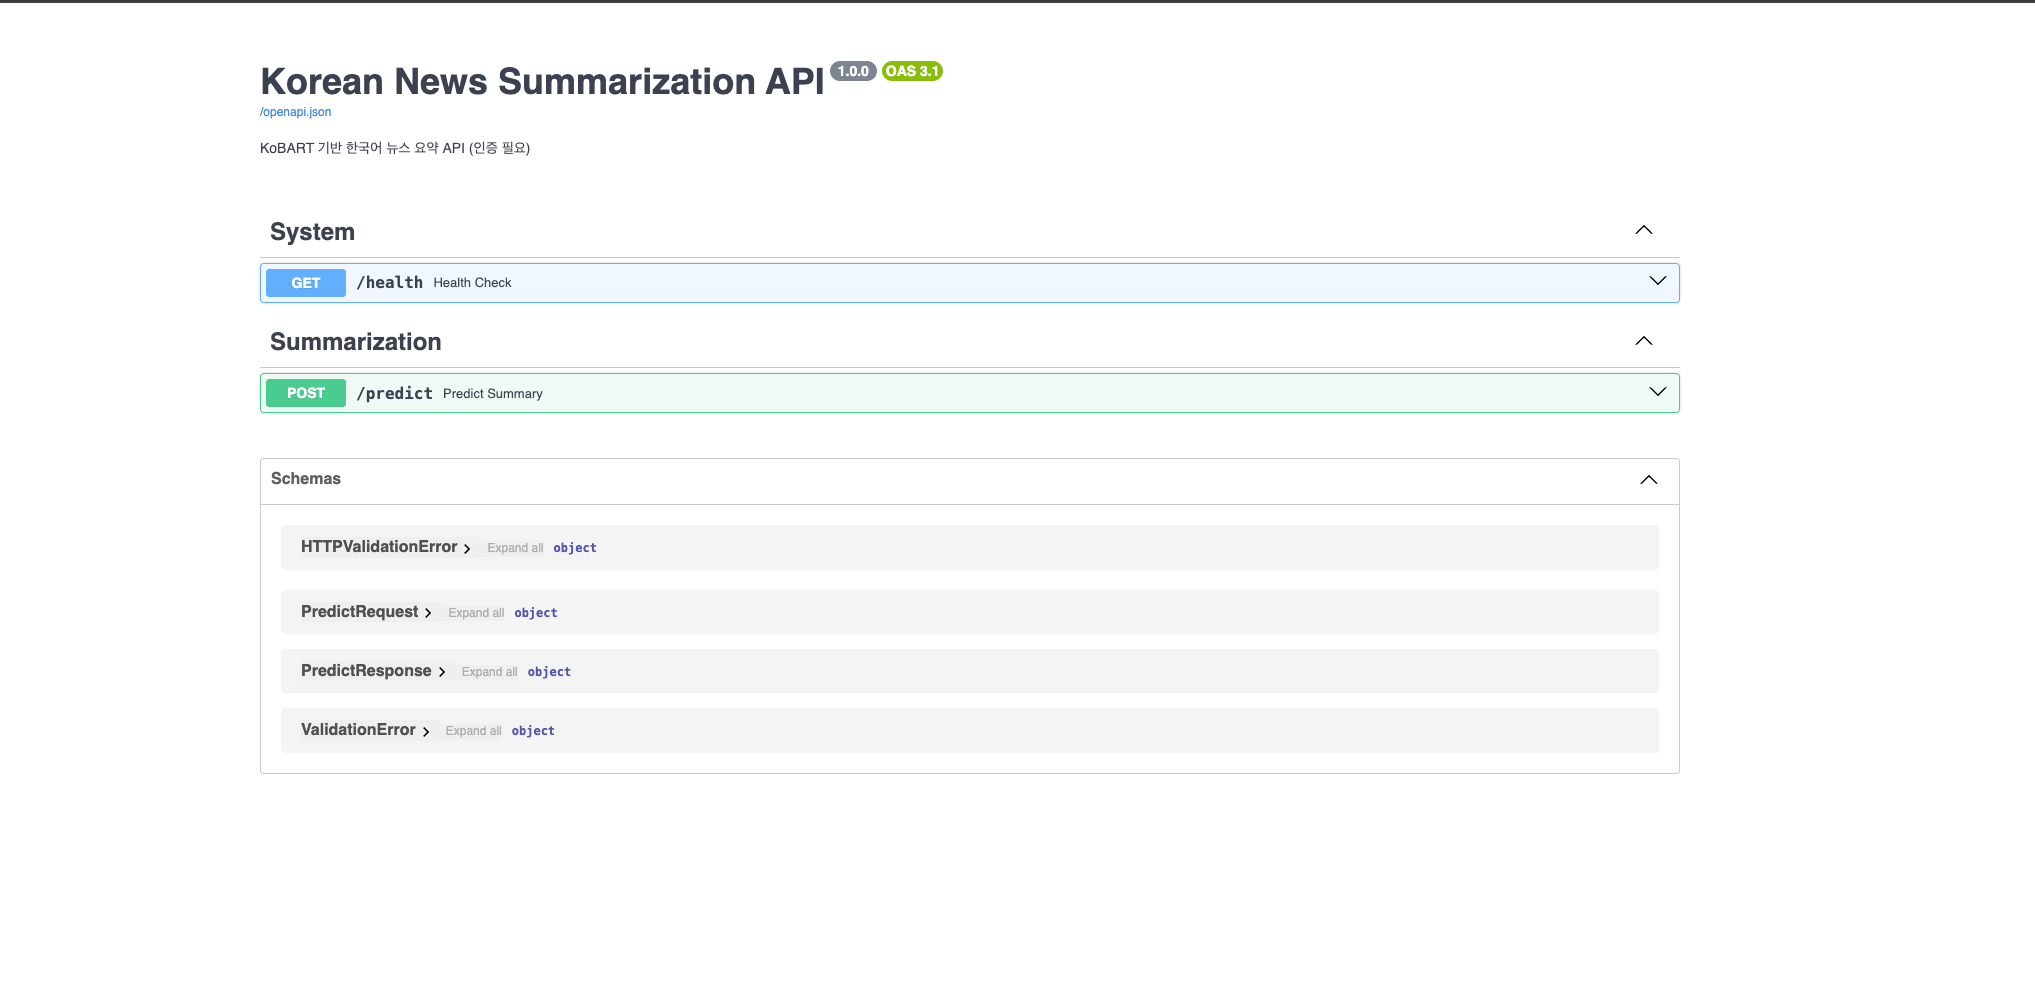

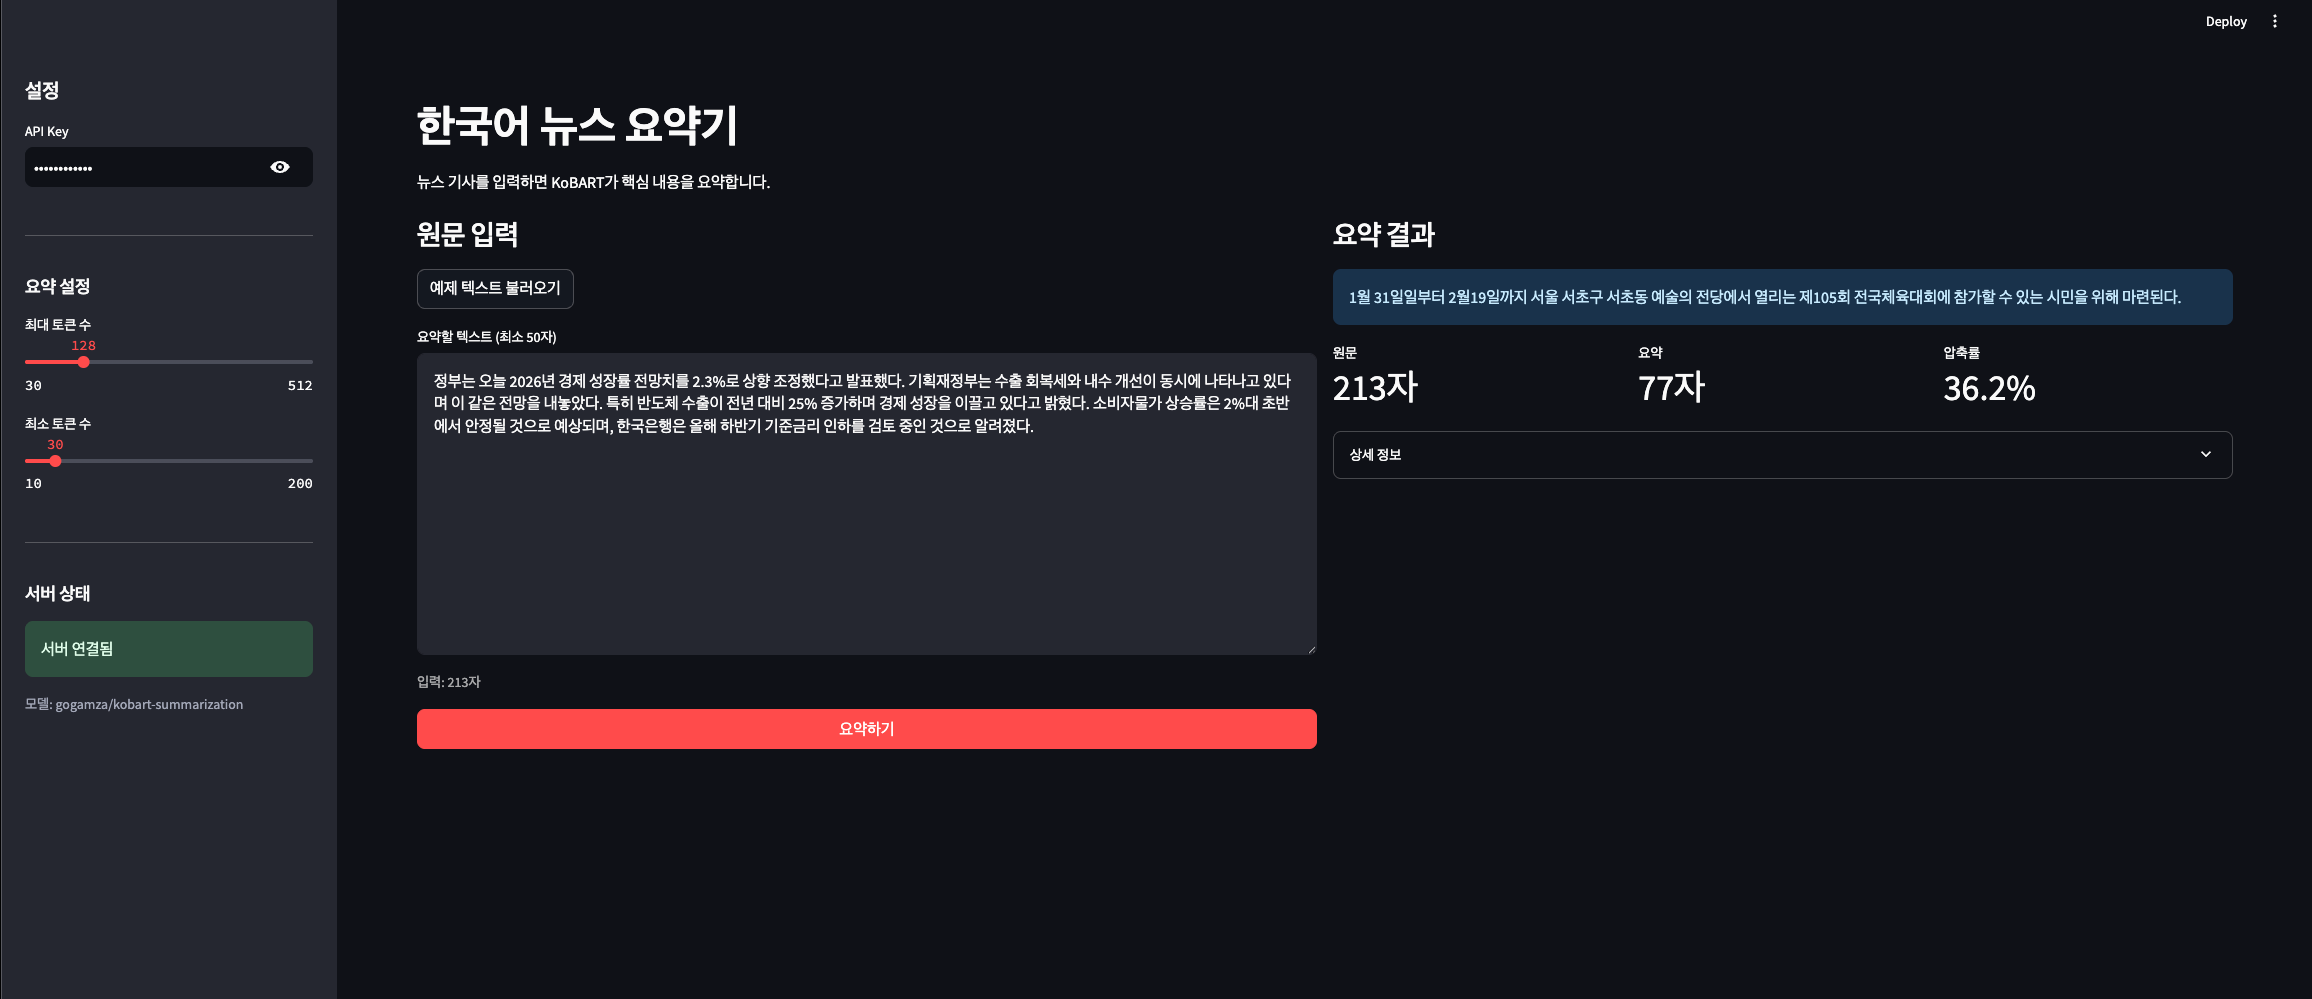